In [1]:
import numpy as np
import pandas as pd

In [2]:
l01_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_0.1/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
l01_fold0["fold"] = [0 for i in range(len(l01_fold0))]
l01_fold0["lambda"] = [0.1 for i in range(len(l01_fold0))]

In [3]:
l01_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_0.1/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
l01_fold1["fold"] = [1 for i in range(len(l01_fold1))]
l01_fold1["lambda"] = [0.1 for i in range(len(l01_fold1))]

In [4]:
l01_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_0.1/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
l01_fold2["fold"] = [2 for i in range(len(l01_fold2))]
l01_fold2["lambda"] = [0.1 for i in range(len(l01_fold2))]

In [5]:
l1_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_1.0/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
l1_fold0["fold"] = [0 for i in range(len(l1_fold0))]
l1_fold0["lambda"] = [1.0 for i in range(len(l1_fold0))]

In [6]:
l1_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_1.0/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
l1_fold1["fold"] = [1 for i in range(len(l1_fold1))]
l1_fold1["lambda"] = [1.0 for i in range(len(l1_fold1))]

In [9]:
l1_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_1.0/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
l1_fold2["fold"] = [2 for i in range(len(l1_fold2))]
l1_fold2["lambda"] = [1.0 for i in range(len(l1_fold2))]

In [8]:
l10_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_10.0/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
l10_fold0["fold"] = [0 for i in range(len(l10_fold0))]
l10_fold0["lambda"] = [10.0 for i in range(len(l10_fold0))]

In [10]:
l10_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_10.0/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
l10_fold1["fold"] = [1 for i in range(len(l10_fold1))]
l10_fold1["lambda"] = [10.0 for i in range(len(l10_fold1))]

In [11]:
l10_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_10.0/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
l10_fold2["fold"] = [2 for i in range(len(l10_fold2))]
l10_fold2["lambda"] = [10.0 for i in range(len(l10_fold2))]

In [12]:
l100_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_100.0/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
l100_fold0["fold"] = [0 for i in range(len(l100_fold0))]
l100_fold0["lambda"] = [100.0 for i in range(len(l100_fold0))]

In [13]:
l100_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_100.0/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
l100_fold1["fold"] = [1 for i in range(len(l100_fold1))]
l100_fold1["lambda"] = [100.0 for i in range(len(l100_fold1))]

In [14]:
l100_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/lambda/lambda_100.0/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
l100_fold2["fold"] = [2 for i in range(len(l100_fold2))]
l100_fold2["lambda"] = [100.0 for i in range(len(l100_fold2))]

In [15]:
df = pd.concat([l01_fold0, l01_fold1, l01_fold2,
                l1_fold0, l1_fold1, l1_fold2,
                l10_fold0, l10_fold1, l10_fold2,
                l100_fold0, l100_fold1, l100_fold2], ignore_index=True)

In [16]:
# summing edits together
df["num_edits"] = df["num_edits_slice0"] + df["num_edits_slice1"]

In [17]:
# optimizations with no edits
counts = df.groupby("lambda")["num_edits"].apply(lambda x: (x == 0).sum())
print(counts)

lambda
0.1       0
1.0       0
10.0      4
100.0    59
Name: num_edits, dtype: int64


In [19]:
# eliminating them
df = df[df["num_edits"] > 0]

In [23]:
# optimizations with edits but not sufficent dot score
dot_counts = df.groupby("lambda")["dot_result"].apply(lambda x: (x <= 0.05).sum())
print(dot_counts)

lambda
0.1      26
1.0      33
10.0     25
100.0    33
Name: dot_result, dtype: int64


In [24]:
len(df[df["dot_result"] <= 0.05])

117

In [25]:
# eliminating them
df = df[df["dot_result"] > 0.05]

In [26]:
# successful optimizations only, average number of edits
avg_num_edits = df.groupby("lambda")["num_edits"].mean()
print(avg_num_edits)

lambda
0.1      1203.376812
1.0      1119.343511
10.0      713.318519
100.0      77.805556
Name: num_edits, dtype: float64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df["dot_diff"] = df["dot_result"] - df["dot_init"]

In [34]:
df["CTCFs_num"] = df["CTCFs_num_slice0"] + df["CTCFs_num_slice1"]

In [35]:
df["FIMO_sum"] = df["FIMO_sum_slice0"] + df["FIMO_sum_slice1"]

In [36]:
df["FIMO_max"] = df[["FIMO_max_slice0", "FIMO_max_slice1"]].max(axis=1)

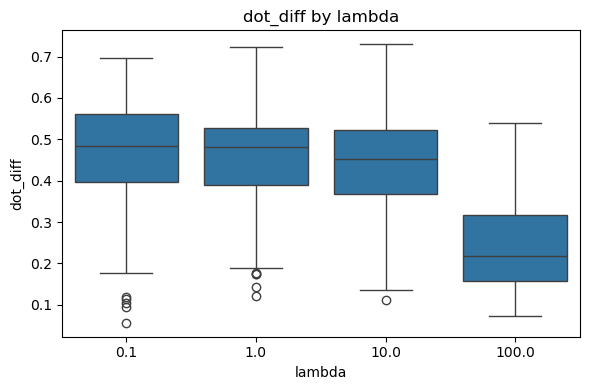

In [37]:
order = sorted(df["lambda"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="dot_diff", order=order)
plt.xlabel("lambda")
plt.ylabel("dot_diff")
plt.title("dot_diff by lambda")
plt.tight_layout()
plt.show()

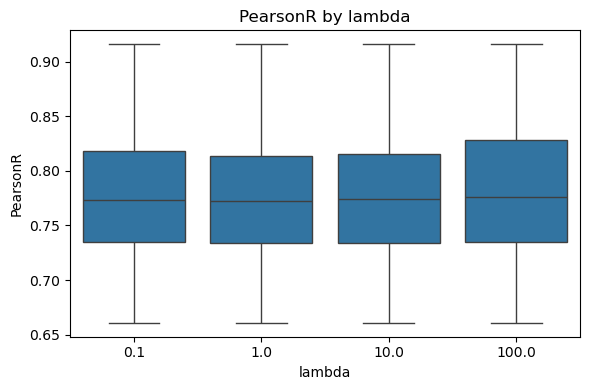

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="PearsonR", order=order)
plt.xlabel("lambda")
plt.ylabel("PearsonR")
plt.title("PearsonR by lambda")
plt.tight_layout()
plt.show()

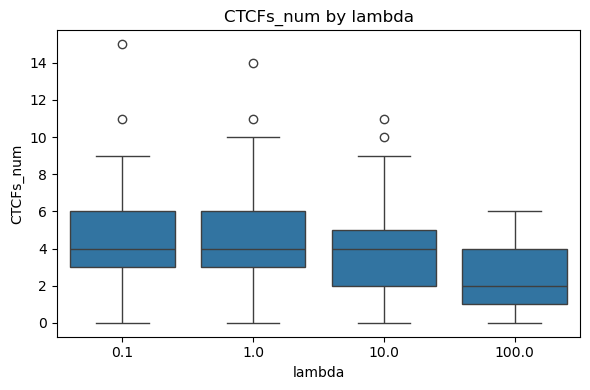

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="CTCFs_num", order=order)
plt.xlabel("lambda")
plt.ylabel("CTCFs_num")
plt.title("CTCFs_num by lambda")
plt.tight_layout()
plt.show()

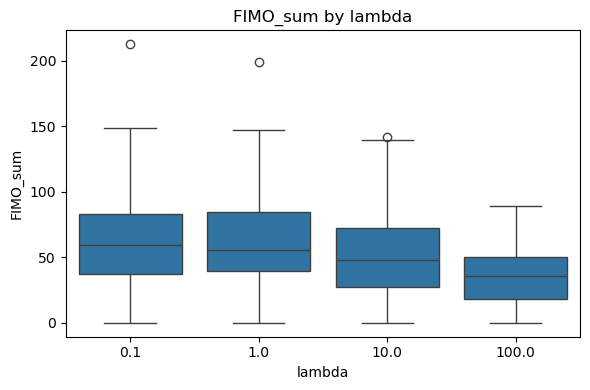

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="FIMO_sum", order=order)
plt.xlabel("lambda")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by lambda")
plt.tight_layout()
plt.show()

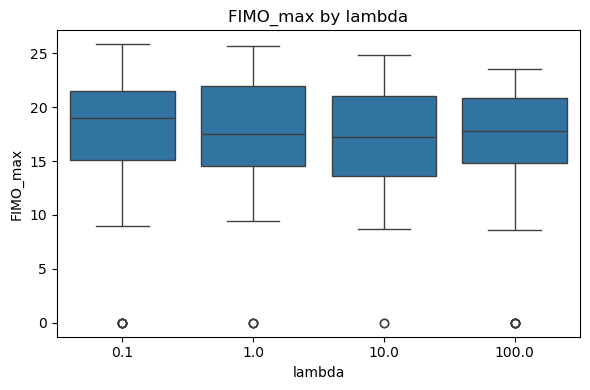

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lambda", y="FIMO_max", order=order)
plt.xlabel("lambda")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by lambda")
plt.tight_layout()
plt.show()